 # Semi-Supervised Label Propagation on MNIST



 This notebook demonstrates:

 - Loading MNIST from raw IDX files

 - Building a **semi-supervised** scenario by hiding most labels

 - Training your custom **LabelPropagation** (sparse k-NN graph)

 - Evaluating both transductive + inductive accuracy

 - Comparing with a **Logistic Regression** supervised baseline

 - Studying the effect of labeled data quantity

 - Visualizing embedding structure with PCA



 Once you run this notebook, send me screenshots of the plots + metrics.

 I will write polished interpretations for your final project.

 ## 1. Imports

In [10]:
import os
import struct
from typing import Tuple, List, Dict

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from rice_ml.semi_supervised.label_propagation import LabelPropagation


plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["axes.grid"] = True



 ## 2. Utilities to load MNIST

In [11]:
def find_data_dir(
    filenames: List[str],
    candidates: List[str] = None,
) -> str:
    if candidates is None:
        candidates = ["datasets", "../datasets", "../../datasets", "./"]

    for d in candidates:
        if all(os.path.exists(os.path.join(d, fn)) for fn in filenames):
            print(f"[INFO] Found data directory: {os.path.abspath(d)}")
            return d

    raise FileNotFoundError(
        f"Could not find all {filenames} in any of {candidates}"
    )


def load_idx_images(path: str) -> np.ndarray:
    with open(path, "rb") as f:
        magic, n, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Bad magic number in image file: {magic}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows, cols)


def load_idx_labels(path: str) -> np.ndarray:
    with open(path, "rb") as f:
        magic, n = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Bad magic number in labels: {magic}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data


def plot_digits_grid(X, y_true, y_pred=None, title="", n_rows=4, n_cols=8):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.5*n_cols, 1.5*n_rows))
    axes = axes.flatten()

    for i in range(n_rows*n_cols):
        ax = axes[i]
        if i < len(X):
            ax.imshow(X[i], cmap="gray")
            ax.axis("off")
            if y_pred is None:
                ax.set_title(f"y={y_true[i]}", fontsize=8)
            else:
                ax.set_title(f"{y_true[i]}/{y_pred[i]}", fontsize=8)
        else:
            ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, classes, title=""):
    fig, ax = plt.subplots()
    im = ax.imshow(cm, cmap="Blues")
    ax.figure.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(len(classes)))
    ax.set_xticklabels(classes)
    ax.set_yticks(np.arange(len(classes)))
    ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    thresh = cm.max() / 2
    for i in range(len(classes)):
        for j in range(len(classes)):
            c = "white" if cm[i, j] > thresh else "black"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=c)

    fig.tight_layout()
    plt.show()



 ## 3. Load MNIST

In [12]:
data_dir = os.path.abspath("../../../datasets/FashionMNIST/raw")
print("Using data directory:", data_dir)

train_images = load_idx_images(os.path.join(data_dir, "train-images-idx3-ubyte"))
train_labels = load_idx_labels(os.path.join(data_dir, "train-labels-idx1-ubyte"))

test_images = load_idx_images(os.path.join(data_dir, "t10k-images-idx3-ubyte"))
test_labels = load_idx_labels(os.path.join(data_dir, "t10k-labels-idx1-ubyte"))

train_X = train_images.reshape(len(train_images), -1).astype(np.float32) / 255.0
test_X = test_images.reshape(len(test_images), -1).astype(np.float32) / 255.0

print(train_X.shape, test_X.shape)



Using data directory: c:\Users\maria\OneDrive - ITBA\2C2025\Machine Learning\Final\INDE-577-Final-Project\datasets\FashionMNIST\raw
(60000, 784) (10000, 784)


 ### 3.1 Subsample to avoid memory issues

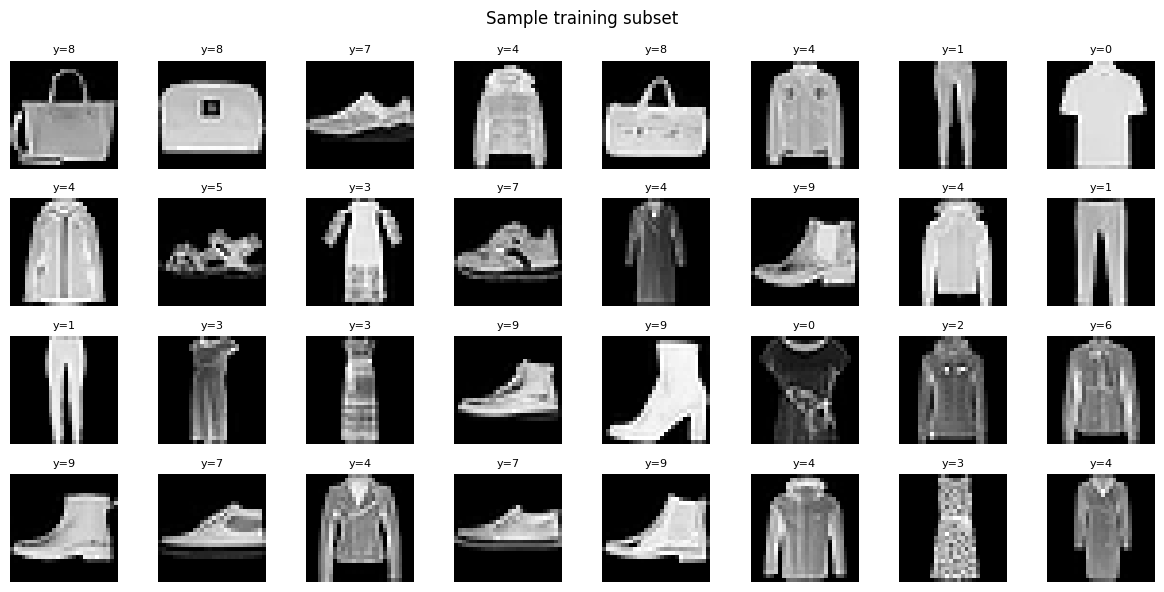

In [13]:
rng = np.random.RandomState(42)

N_TRAIN_GRAPH = 3000
N_TEST_EVAL = 1000

idx_train = rng.choice(train_X.shape[0], N_TRAIN_GRAPH, replace=False)
idx_test = rng.choice(test_X.shape[0], N_TEST_EVAL, replace=False)

X_graph = train_X[idx_train]
y_graph_true = train_labels[idx_train]

X_test_eval = test_X[idx_test]
y_test_eval = test_labels[idx_test]

plot_digits_grid(
    X_graph[:32].reshape(-1, 28, 28),
    y_graph_true[:32],
    title="Sample training subset"
)



 ## 4. Create semi-supervised labels

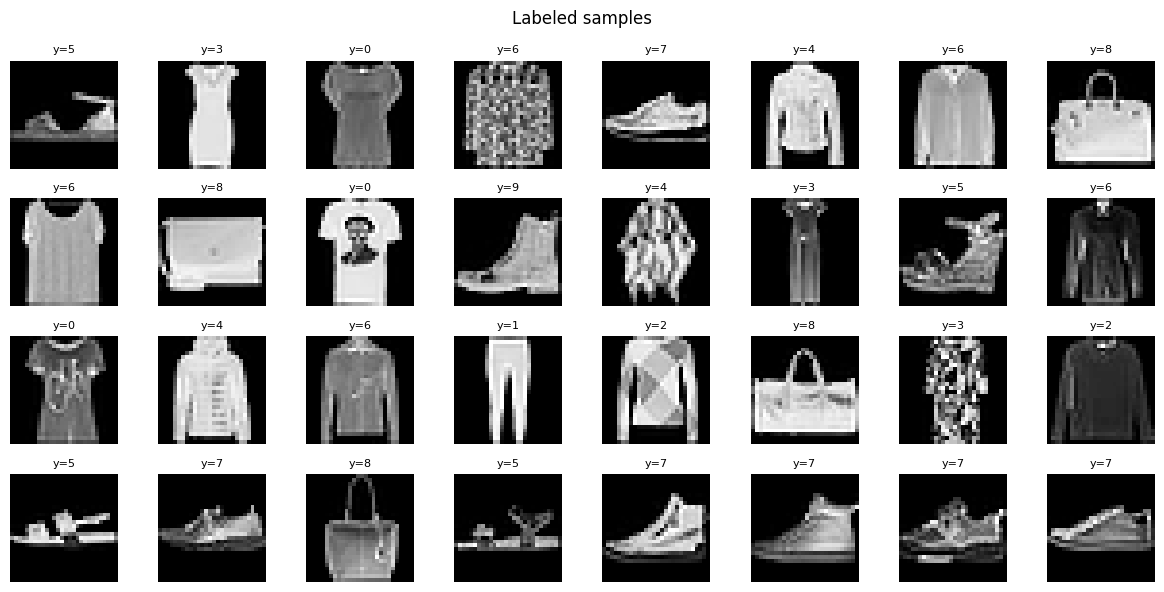

In [14]:
def make_semi_supervised(y, n_labeled_per_class, seed=42):
    rng_local = np.random.RandomState(seed)
    y = np.asarray(y).astype(int)
    y_semi = np.full_like(y, -1)

    labeled_mask = np.zeros_like(y, dtype=bool)

    for c in np.unique(y):
        idx = np.where(y == c)[0]
        k = min(n_labeled_per_class, len(idx))
        chosen = rng_local.choice(idx, k, replace=False)
        y_semi[chosen] = c
        labeled_mask[chosen] = True

    return y_semi, labeled_mask, ~labeled_mask


N_LABELED_PER_CLASS = 10
y_graph_semi, mask_labeled, mask_unlabeled = make_semi_supervised(
    y_graph_true, N_LABELED_PER_CLASS
)

plot_digits_grid(
    X_graph[mask_labeled][:32].reshape(-1, 28, 28),
    y_graph_true[mask_labeled][:32],
    title="Labeled samples"
)



 ## 5. Train Label Propagation model

In [15]:
model = LabelPropagation(
    n_neighbors=10,
    alpha=0.99,
    max_iter=300,
    tol=1e-4,
    verbose=True
)

model.fit(X_graph, y_graph_semi)

print("Converged:", model.converged_)
print("Iterations:", model.n_iter_)
print("Classes:", model.classes_)



[LP] Building sparse k-NN graph (k=10)...
[LP] Starting propagation...
  iter 000, delta=10.292314
  iter 001, delta=2.522081
  iter 002, delta=0.787413
  iter 003, delta=0.348474
  iter 004, delta=0.202282
  iter 005, delta=0.139889
  iter 006, delta=0.106140
  iter 007, delta=0.085371
  iter 008, delta=0.071293
  iter 009, delta=0.061127
  iter 010, delta=0.053380
  iter 011, delta=0.047237
  iter 012, delta=0.042213
  iter 013, delta=0.038013
  iter 014, delta=0.034444
  iter 015, delta=0.031375
  iter 016, delta=0.028715
  iter 017, delta=0.026395
  iter 018, delta=0.024360
  iter 019, delta=0.022569
  iter 020, delta=0.020986
  iter 021, delta=0.019582
  iter 022, delta=0.018331
  iter 023, delta=0.017213
  iter 024, delta=0.016210
  iter 025, delta=0.015306
  iter 026, delta=0.014489
  iter 027, delta=0.013746
  iter 028, delta=0.013069
  iter 029, delta=0.012448
  iter 030, delta=0.011879
  iter 031, delta=0.011353
  iter 032, delta=0.010867
  iter 033, delta=0.010416
  iter 034

 ## 6. Evaluation

In [16]:
# Transductive
y_graph_pred = model.predict()

acc_all = accuracy_score(y_graph_true, y_graph_pred)
acc_lab = accuracy_score(y_graph_true[mask_labeled], y_graph_pred[mask_labeled])
acc_unlab = accuracy_score(y_graph_true[mask_unlabeled], y_graph_pred[mask_unlabeled])

print("Transductive accuracy (all):", acc_all)
print("  labeled only:", acc_lab)
print("  unlabeled only:", acc_unlab)

# Inductive
y_test_pred = model.predict(X_test_eval)
acc_test = accuracy_score(y_test_eval, y_test_pred)

print("\nInductive test accuracy:", acc_test)



Transductive accuracy (all): 0.5793333333333334
  labeled only: 0.96
  unlabeled only: 0.5662068965517242

Inductive test accuracy: 0.562


 ### Confusion matrices

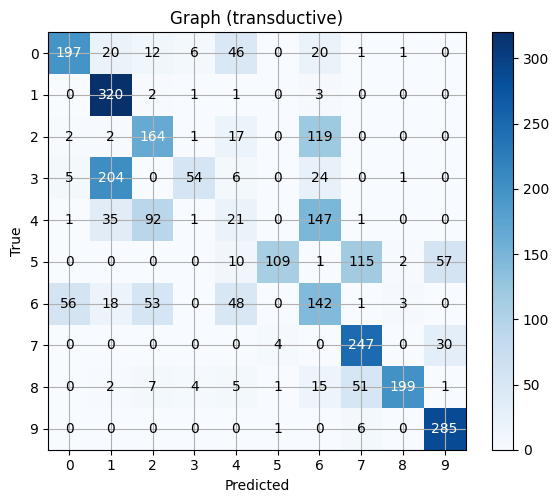

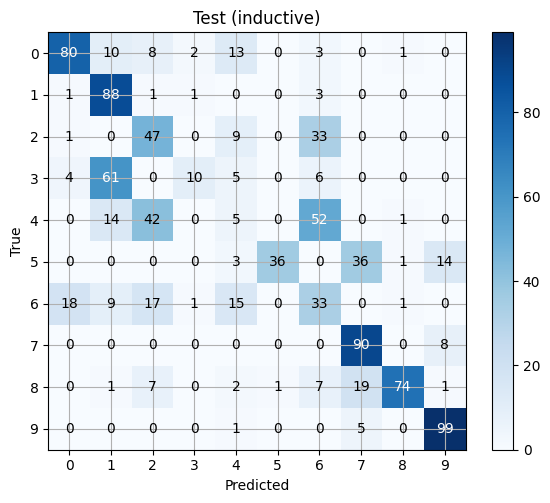

Classification report – inductive:
              precision    recall  f1-score   support

           0       0.77      0.68      0.72       117
           1       0.48      0.94      0.64        94
           2       0.39      0.52      0.44        90
           3       0.71      0.12      0.20        86
           4       0.09      0.04      0.06       114
           5       0.97      0.40      0.57        90
           6       0.24      0.35      0.29        94
           7       0.60      0.92      0.73        98
           8       0.95      0.66      0.78       112
           9       0.81      0.94      0.87       105

    accuracy                           0.56      1000
   macro avg       0.60      0.56      0.53      1000
weighted avg       0.60      0.56      0.54      1000



In [17]:
cm_graph = confusion_matrix(y_graph_true, y_graph_pred)
cm_test = confusion_matrix(y_test_eval, y_test_pred)

plot_confusion_matrix(cm_graph, np.arange(10), "Graph (transductive)")
plot_confusion_matrix(cm_test, np.arange(10), "Test (inductive)")


print("Classification report – inductive:")
print(classification_report(y_test_eval, y_test_pred))



 ### Correct vs incorrect predictions

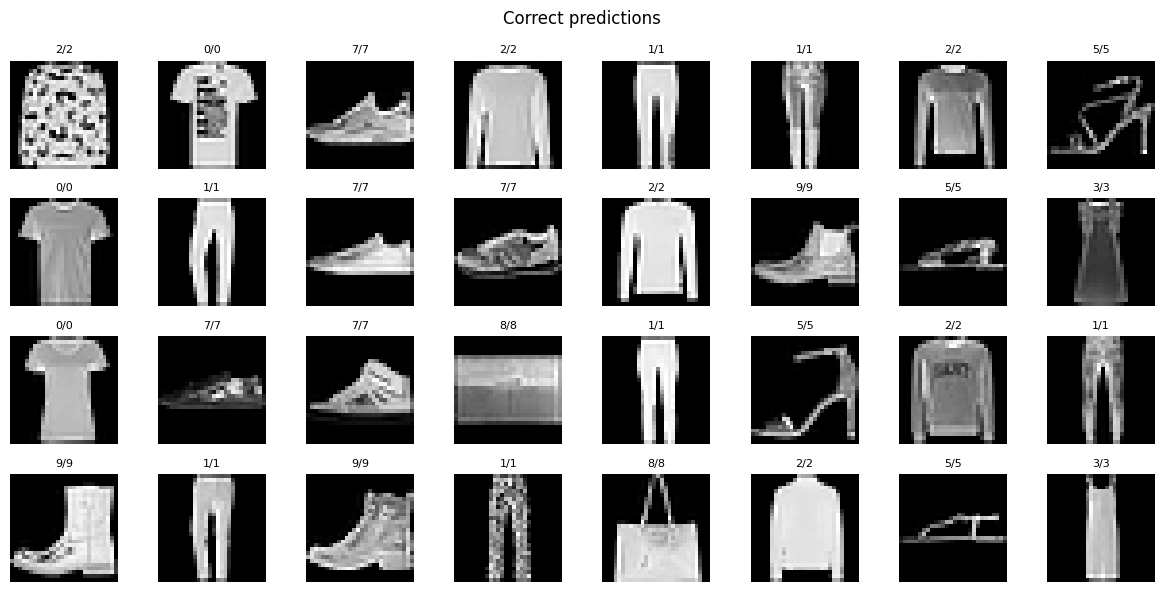

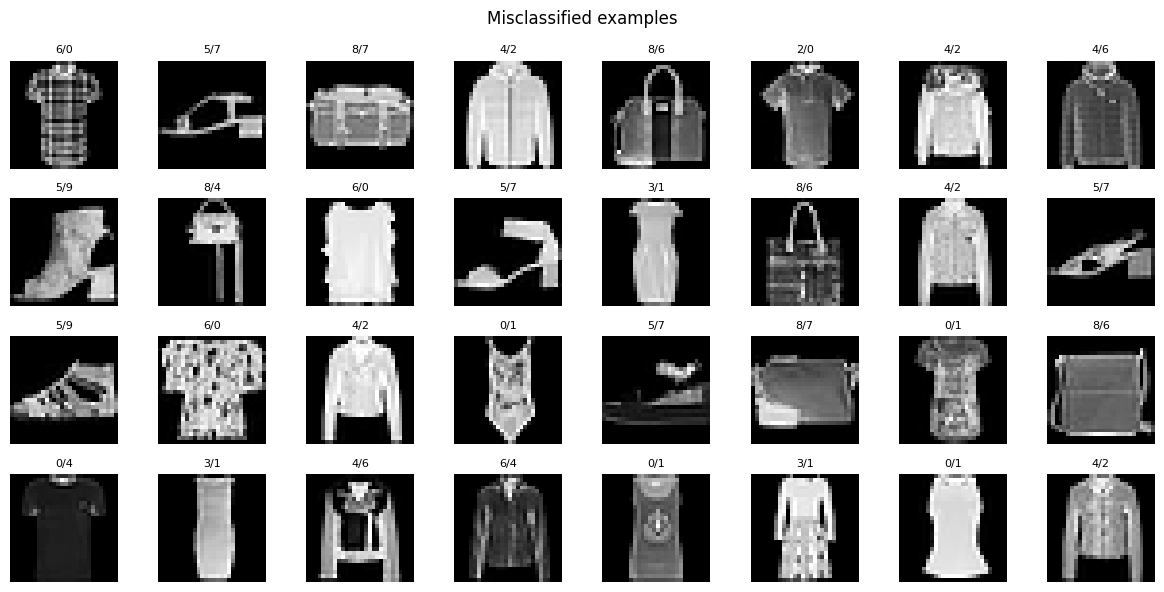

In [18]:
correct = np.where(y_test_pred == y_test_eval)[0]
incorrect = np.where(y_test_pred != y_test_eval)[0]

plot_digits_grid(
    X_test_eval[correct][:32].reshape(-1, 28, 28),
    y_test_eval[correct][:32],
    y_pred=y_test_pred[correct][:32],
    title="Correct predictions"
)

plot_digits_grid(
    X_test_eval[incorrect][:32].reshape(-1, 28, 28),
    y_test_eval[incorrect][:32],
    y_pred=y_test_pred[incorrect][:32],
    title="Misclassified examples"
)



 ## 7. Supervised baseline: Logistic Regression

c:\Users\maria\OneDrive - ITBA\2C2025\Machine Learning\Final\INDE-577-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Baseline LR accuracy: 0.704


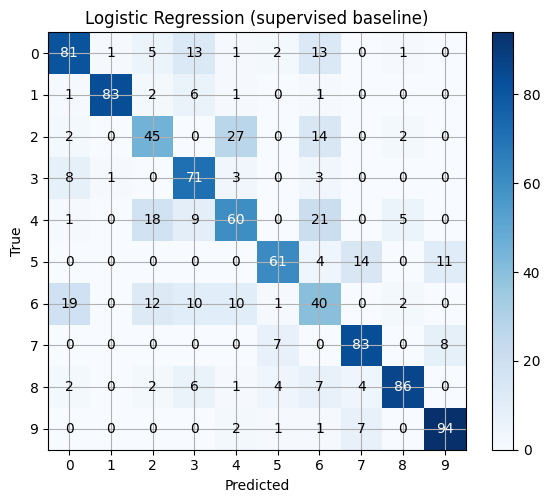

In [19]:
X_lab = X_graph[mask_labeled]
y_lab = y_graph_true[mask_labeled]

lr = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial",
    n_jobs=-1
)
lr.fit(X_lab, y_lab)

y_test_lr = lr.predict(X_test_eval)
acc_lr = accuracy_score(y_test_eval, y_test_lr)

print("Baseline LR accuracy:", acc_lr)

plot_confusion_matrix(
    confusion_matrix(y_test_eval, y_test_lr),
    np.arange(10),
    "Logistic Regression (supervised baseline)"
)



 ## 8. Effect of number of labeled samples

c:\Users\maria\OneDrive - ITBA\2C2025\Machine Learning\Final\INDE-577-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\maria\OneDrive - ITBA\2C2025\Machine Learning\Final\INDE-577-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\maria\OneDrive - ITBA\2C2025\Machine Learning\Final\INDE-577-Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to

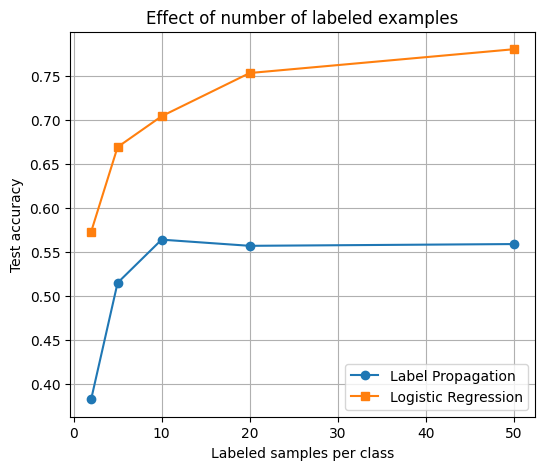

In [20]:
label_counts = [2, 5, 10, 20, 50]
lp_acc = []
lr_acc = []

for k in label_counts:
    y_semi_k, mask_l_k, _ = make_semi_supervised(y_graph_true, k)

    lp_k = LabelPropagation(
        n_neighbors=10,
        alpha=0.99,
        max_iter=200,
        tol=1e-4,
        verbose=False
    )

    lp_k.fit(X_graph, y_semi_k)
    y_test_lp_k = lp_k.predict(X_test_eval)
    lp_acc.append(accuracy_score(y_test_eval, y_test_lp_k))

    # Baseline
    lr_k = LogisticRegression(max_iter=1000, multi_class="multinomial", n_jobs=-1)
    lr_k.fit(X_graph[mask_l_k], y_graph_true[mask_l_k])
    y_test_lr_k = lr_k.predict(X_test_eval)
    lr_acc.append(accuracy_score(y_test_eval, y_test_lr_k))

plt.plot(label_counts, lp_acc, marker="o", label="Label Propagation")
plt.plot(label_counts, lr_acc, marker="s", label="Logistic Regression")
plt.xlabel("Labeled samples per class")
plt.ylabel("Test accuracy")
plt.title("Effect of number of labeled examples")
plt.legend()
plt.grid(True)
plt.show()



 ## 9. PCA visualization of clusters

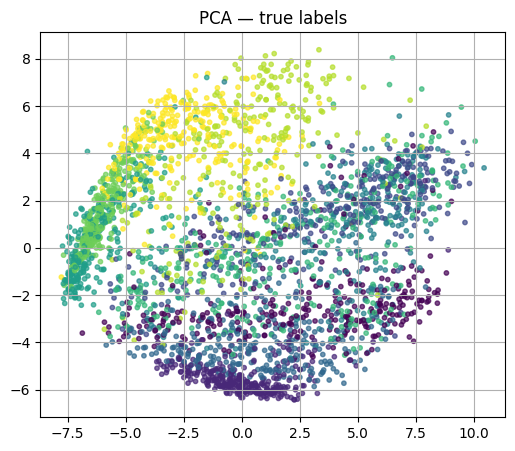

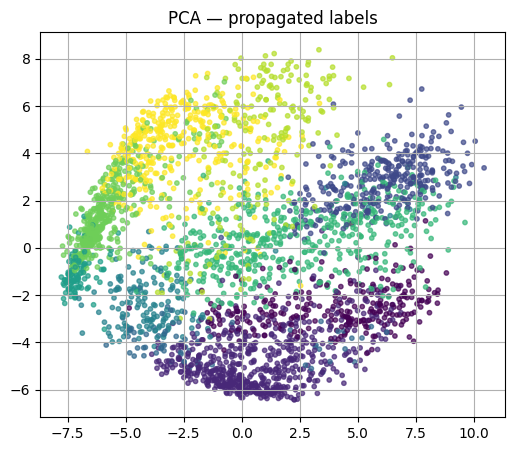

In [21]:
pca = PCA(n_components=2, random_state=42)
X2d = pca.fit_transform(X_graph)

plt.scatter(X2d[:, 0], X2d[:, 1], c=y_graph_true, s=10, alpha=0.7)
plt.title("PCA — true labels")
plt.show()

plt.scatter(X2d[:, 0], X2d[:, 1], c=y_graph_pred, s=10, alpha=0.7)
plt.title("PCA — propagated labels")
plt.show()

